# Capstone — Refresh / Content Opportunity Scoring

This notebook synthesizes results already produced and validated in `w01`–`w07`. It does not re-run the full pipeline from scratch — it pulls the confirmed numbers from `outputs/model_report.md`, `outputs/refresh_queue.csv`, and the signal audit, and assembles them into the shape of the deployed paper.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Question:** Which existing content items should be prioritized for refresh review, and does a learned model rank them meaningfully better than a transparent hand-rule baseline?

**Decision supported:** which pages a content/editorial team reviews first, this week, out of a large backlog — a weekly triage decision, not an automated publishing action.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [1]:
# Synthesis only — see w01_research_question.ipynb and w03_data_contract.ipynb for the full data audit.
data_summary = {
    'source': 'content_refresh_anonymized.csv (FlyRank ML Internship starter release)',
    'rows': 30000,
    'pseudonymized_clients': 32,
    'window': 'trailing 90-day activity totals + 30d/30d prior comparison window',
    'excluded': 'client names, domains, URLs, titles, keywords, raw queries, credentials — none shipped in this release',
    'ids_usage': 'content_id/client_id used only for grouping and client-holdout splits, never as model features',
}
for k, v in data_summary.items():
    print(f'{k}: {v}')

source: content_refresh_anonymized.csv (FlyRank ML Internship starter release)
rows: 30000
pseudonymized_clients: 32
window: trailing 90-day activity totals + 30d/30d prior comparison window
excluded: client names, domains, URLs, titles, keywords, raw queries, credentials — none shipped in this release
ids_usage: content_id/client_id used only for grouping and client-holdout splits, never as model features


This is a small anonymized teaching slice, not the full ~79M-row warehouse — appropriate for this capstone's scope. Rows are content items with ≥1 impression and ≥90 days of age; duplicates by `content_id` are dropped. No raw private client data appears anywhere in this repo (see `DATA_USE.md`).

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [2]:
methodology = {
    'label': "is_declining_label = (trend_direction == 'down')",
    'leakage_excluded': ['trend_direction', 'trend_pct'],
    'features': 'MODEL_NUMERIC_FEATURES + MODEL_CATEGORICAL_FEATURES from scripts/ml_utils.py '
                '(impressions/clicks/sessions logs, avg_position, ctr, engagement/scroll rate, '
                'content age/freshness, word/char count, tiers, content_type, main_intent, competition_level)',
    'baseline': 'transparent weighted hand-rule: 0.40*visibility + 0.30*freshness_risk '
                '+ 0.25*position_opportunity + 0.05*depth_gap',
    'models_compared': ['logistic_regression', 'decision_tree', 'random_forest'],
    'validation_split': 'client_holdout (~20% of clients held out entirely — no client appears in both '
                         'train and test) with stratified_row_holdout as documented fallback',
    'selection_metric': 'precision_at_50 (reviewer only checks top ~50 pages/week)',
    'leakage_checks_done': 'w03_feature_leakage_check.ipynb — confirmed trend_direction/trend_pct excluded, '
                            'IDs used for grouping only',
}
for k, v in methodology.items():
    print(f'{k}: {v}\n')

label: is_declining_label = (trend_direction == 'down')

leakage_excluded: ['trend_direction', 'trend_pct']

features: MODEL_NUMERIC_FEATURES + MODEL_CATEGORICAL_FEATURES from scripts/ml_utils.py (impressions/clicks/sessions logs, avg_position, ctr, engagement/scroll rate, content age/freshness, word/char count, tiers, content_type, main_intent, competition_level)

baseline: transparent weighted hand-rule: 0.40*visibility + 0.30*freshness_risk + 0.25*position_opportunity + 0.05*depth_gap

models_compared: ['logistic_regression', 'decision_tree', 'random_forest']

validation_split: client_holdout (~20% of clients held out entirely — no client appears in both train and test) with stratified_row_holdout as documented fallback

selection_metric: precision_at_50 (reviewer only checks top ~50 pages/week)

leakage_checks_done: w03_feature_leakage_check.ipynb — confirmed trend_direction/trend_pct excluded, IDs used for grouping only



## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

                 model  roc_auc  avg_precision  precision_at_50
0       baseline_rules    0.627          0.468             0.24
1  logistic_regression    0.700          0.522             0.40
2        decision_tree    0.742          0.575             0.54
3        random_forest    0.750          0.618             0.74


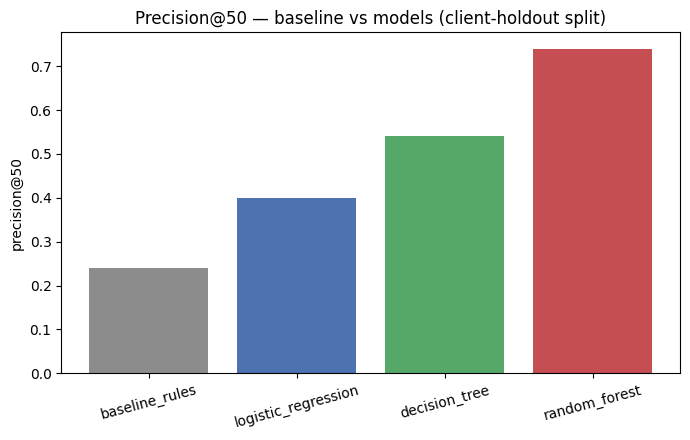


Best model: random_forest — 3.1x lift over the baseline rule on the same held-out clients.


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Confirmed numbers from outputs/model_report.md (client_holdout split)
results = pd.DataFrame({
    'model': ['baseline_rules', 'logistic_regression', 'decision_tree', 'random_forest'],
    'roc_auc': [0.627, 0.700, 0.742, 0.750],
    'avg_precision': [0.468, 0.522, 0.575, 0.618],
    'precision_at_50': [0.240, 0.400, 0.540, 0.740],
})
print(results)

plt.figure(figsize=(7, 4.5))
colors = ['#8C8C8C', '#4C72B0', '#55A868', '#C44E52']
plt.bar(results['model'], results['precision_at_50'], color=colors)
plt.title('Precision@50 — baseline vs models (client-holdout split)')
plt.ylabel('precision@50')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(f"\nBest model: random_forest — {results.loc[3,'precision_at_50']/results.loc[0,'precision_at_50']:.1f}x "
      f"lift over the baseline rule on the same held-out clients.")

Random Forest is the best model by `precision_at_50` (0.740), a ~3x lift over the transparent baseline rule (0.240), on a client-holdout split — no client's pages appear in both train and test, so this is a same-split, apples-to-apples comparison, not a lucky row split.

## 5. Limitations

*What this work cannot claim.*

- This model predicts an **observed 90-day pattern** (`trend_direction == down`), not a forecast of future decline — it is decision-support for **review prioritization**, not a prediction of what Google's algorithm will do next.
- Trained and evaluated on a **single anonymized 30k-row snapshot** covering 32 clients; results may not generalize to the full ~79M-row warehouse or to clients outside this slice.
- `random_forest`'s exact Precision@50 is **library-version sensitive** (documented range ~0.68–0.74 across scikit-learn/numpy versions); the stable, defensible claim is the ~3x lift, not the third decimal.
- The signal audit (`w04_signal_audit.ipynb`) found staleness and word count alone to be **MIXED** signals — only CTR-vs-position and the combined low-CTR rule were **CONFIRMED**. Single-signal explanations should be avoided.
- No causal or refresh-impact claim is made anywhere — all findings are **observed / measured / directional / decision-support**.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

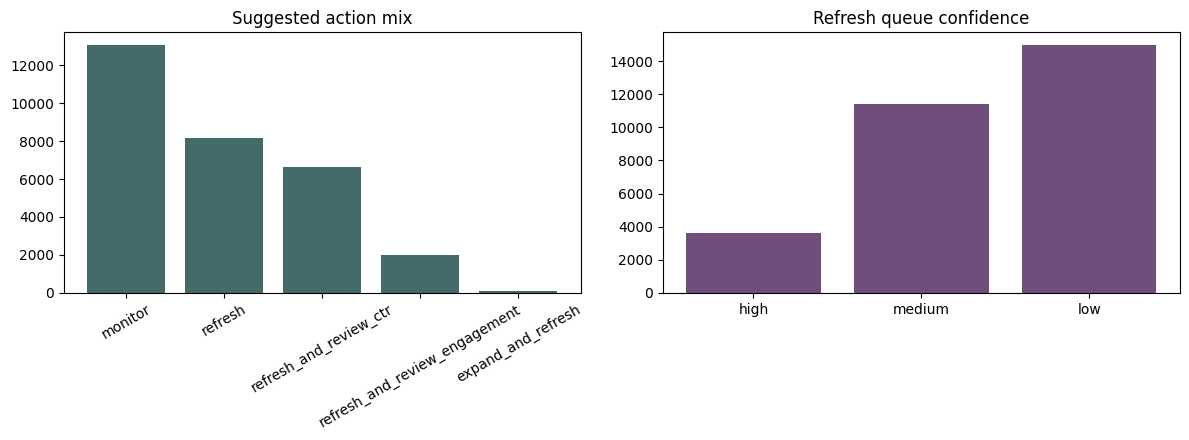

In [4]:
# Confirmed action mix from outputs/model_report.md / refresh_queue.csv
action_counts = pd.Series({
    'monitor': 13083,
    'refresh': 8188,
    'refresh_and_review_ctr': 6654,
    'refresh_and_review_engagement': 1993,
    'expand_and_refresh': 82,
})
confidence_counts = pd.Series({'high': 3602, 'medium': 11398, 'low': 15000})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(action_counts.index, action_counts.values, color='#426B69')
axes[0].set_title('Suggested action mix')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(confidence_counts.index, confidence_counts.values, color='#6F4E7C')
axes[1].set_title('Refresh queue confidence')
plt.tight_layout()
plt.show()

**Action playbook, in priority order:**

1. **High-confidence `refresh_and_review_ctr`** (score ≥ p80, ≥500 impressions, ≥10 sessions, model probability ≥ 0.5) — visible pages under-capturing clicks relative to position; review metadata/snippet first.
2. **`expand_and_refresh`** — thin content still earning meaningful impressions; smallest group (82 items) but highest-leverage fix.
3. **`refresh` / `refresh_and_review_engagement`** — declining-with-demand or stale visible pages; standard content refresh queue.
4. **`monitor`** — everything else; no action needed yet, re-score next cycle.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [5]:
artifacts = [
    'outputs/model_report.md',
    'outputs/refresh_queue.csv',
    'outputs/charts/action_mix.svg',
    'outputs/charts/confidence_mix.svg',
    'outputs/charts/top_reason_codes.svg',
    'outputs/charts/top_feature_importance.svg',
    'outputs/charts/trend_distribution.svg',
    'work/notebooks/w04_signal_audit.ipynb (distribution + signal-verdict charts)',
    'this notebook\'s precision@50 and action-mix charts (generated above)',
]
for a in artifacts:
    print('-', a)

- outputs/model_report.md
- outputs/refresh_queue.csv
- outputs/charts/action_mix.svg
- outputs/charts/confidence_mix.svg
- outputs/charts/top_reason_codes.svg
- outputs/charts/top_feature_importance.svg
- outputs/charts/trend_distribution.svg
- work/notebooks/w04_signal_audit.ipynb (distribution + signal-verdict charts)
- this notebook's precision@50 and action-mix charts (generated above)


These are the exact charts and tables the deployed paper's Results and Recommendations sections embed — generated once here, then copied/screenshotted into the paper's HTML/Markdown page at deploy time.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.